# 文件: chart_22_1.py

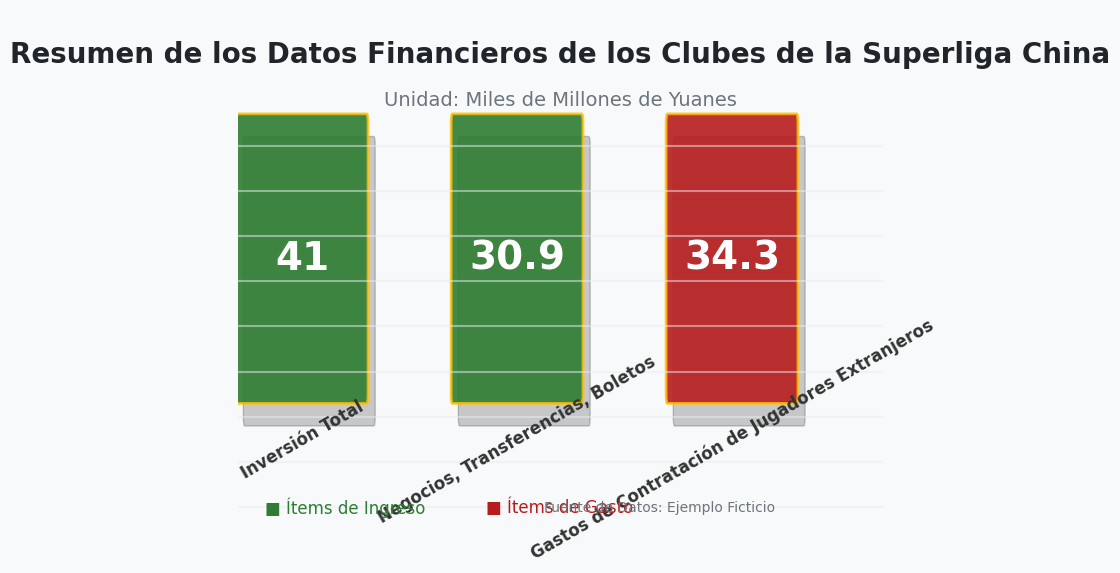

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Datos
etiquetas = ["Inversión Total", "Negocios, Transferencias, Boletos", "Gastos de Contratación de Jugadores Extranjeros"]
valores = [41, 30.9, 34.3]
colores = ["#2E7D32", "#2E7D32", "#B71C1C"]  # Verde y Rojo
color_resaltado = "#FFC107"  # Resaltado amarillo

# Crear el lienzo con altura aumentada para evitar superposiciones
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f8f9fa')  # Aumentar el ancho del lienzo
ax.set_ylim(0, 1.2)  # Ampliar el rango del eje y
ax.set_xlim(0, len(valores) * 3)  # Ampliar el rango del eje x, para dar más espacio a las etiquetas inclinadas
ax.axis('off')

# Dibujar la cuadrícula de fondo
for i in range(1, 10):
    ax.axhline(y=i*0.1, color='#e9ecef', linestyle='-', alpha=0.5)

# Dibujar los bloques de datos con más espaciado
for i in range(len(valores)):
    # Agregar efecto de sombra
    sombra = patches.FancyBboxPatch(
        (i * 3 + 0.1, 0.3), 1.8, 0.6,  # Aumentar el ancho y el intervalo de posición de los bloques
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor='black', alpha=0.2
    )
    ax.add_patch(sombra)
    
    # Dibujar el bloque principal
    rect = patches.FancyBboxPatch(
        (i * 3, 0.35), 1.8, 0.6,  # Aumentar el ancho del bloque
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor=colores[i], edgecolor="none", alpha=0.9
    )
    ax.add_patch(rect)
    
    # Agregar resaltado del borde
    resaltado = patches.FancyBboxPatch(
        (i * 3, 0.35), 1.8, 0.6,  # Aumentar el ancho del bloque
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor='none', edgecolor=color_resaltado, 
        linewidth=2, alpha=0.8
    )
    ax.add_patch(resaltado)
    
    # Dibujar el texto del valor
    ax.text(
        i * 3 + 0.9, 0.65, f"{valores[i]}",  # Ajustar la posición del valor
        ha="center", va="center", fontsize=28, 
        color="white", fontweight='bold',
        bbox=dict(facecolor='none', edgecolor='none')
    )

# Agregar el título
ax.text(
    (len(valores) * 3) / 2, 1.1, "Resumen de los Datos Financieros de los Clubes de la Superliga China", 
    ha="center", va="center", fontsize=20, 
    color="#212529", fontweight='bold'
)

# Agregar el subtítulo
ax.text(
    (len(valores) * 3) / 2, 1.0, "Unidad: Miles de Millones de Yuanes", 
    ha="center", va="center", fontsize=14, 
    color="#6c757d"
)

# Dibujar las etiquetas con una rotación de 30 grados
for i, etiqueta in enumerate(etiquetas):
    ax.text(
        i * 3 + 0.9, 0.25, etiqueta,  # Ajustar la posición de la etiqueta
        ha="center", va="center", fontsize=12, 
        color="#333333", fontweight='bold',
        rotation=30  # Establecer el ángulo de inclinación
    )

# Ajustar la posición de la leyenda
ax.text(
    1.5, 0.1, "■ Ítems de Ingreso",  # Ajustar la posición de la leyenda
    ha="center", va="center", fontsize=12, 
    color="#2E7D32"
)
ax.text(
    4.5, 0.1, "■ Ítems de Gasto",  # Ajustar la posición de la leyenda
    ha="center", va="center", fontsize=12, 
    color="#B71C1C"
)

# Ajustar la posición de la fuente de datos
ax.text(
    (len(valores) * 3) - 1.5, 0.1, "Fuente de Datos: Ejemplo Ficticio", 
    ha="right", va="center", fontsize=10, 
    color="#6c757d"
)

# Ajustar finamente el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# 文件: chart_22_2.py

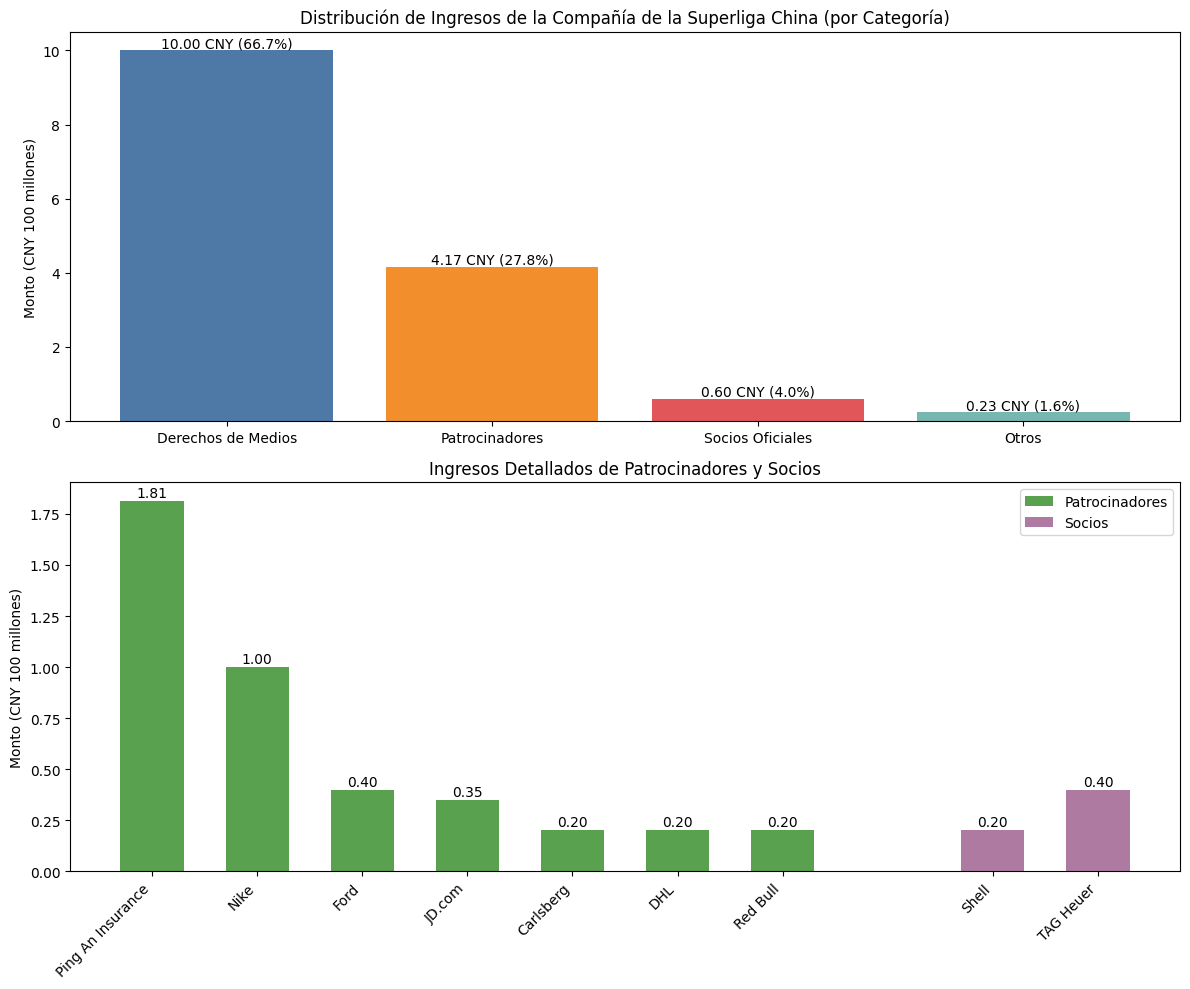

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
ingresos_totales = 15
derechos_medios = 10
patrocinadores = {
    "Ping An Insurance": 1.815,
    "Nike": 1,
    "Ford": 0.4,
    "JD.com": 0.35,
    "Carlsberg": 0.2,
    "DHL": 0.2,
    "Red Bull": 0.2
}
socios = {
    "Shell": 0.2,
    "TAG Heuer": 0.4
}

# Calcular otros ingresos
otros_ingresos = ingresos_totales - derechos_medios - sum(patrocinadores.values()) - sum(socios.values())

# Crear figura
plt.figure(figsize=(12, 10))

# Preparar datos para el gráfico de barras
categorias = ["Derechos de Medios", "Patrocinadores", "Socios Oficiales", "Otros"]
valores = [derechos_medios, sum(patrocinadores.values()), sum(socios.values()), otros_ingresos]
colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# Graficar el gráfico de barras principal - ingresos por categoría
plt.subplot(2, 1, 1)
barras = plt.bar(categorias, valores, color=colores)
plt.title('Distribución de Ingresos de la Compañía de la Superliga China (por Categoría)')
plt.ylabel('Monto (CNY 100 millones)')

# Agregar etiquetas de valor en las barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.2f} CNY ({altura/ingresos_totales*100:.1f}%)',
             ha='center', va='bottom')

# Graficar el gráfico de barras detallado para patrocinadores y socios
plt.subplot(2, 1, 2)

# Combinar datos de patrocinadores y socios
nombres_patrocinadores = list(patrocinadores.keys())
valores_patrocinadores = list(patrocinadores.values())
nombres_socios = list(socios.keys())
valores_socios = list(socios.values())

# Establecer posiciones de las barras
x_patrocinadores = np.arange(len(nombres_patrocinadores))
x_socios = np.arange(len(nombres_socios)) + len(nombres_patrocinadores) + 1

# Graficar barras de patrocinadores
plt.bar(x_patrocinadores, valores_patrocinadores, width=0.6, label='Patrocinadores', color='#59a14f')
# Graficar barras de socios
plt.bar(x_socios, valores_socios, width=0.6, label='Socios', color='#af7aa1')

# Establecer etiquetas y marcas del eje x
plt.xticks(list(x_patrocinadores) + list(x_socios), nombres_patrocinadores + nombres_socios, rotation=45, ha='right')
plt.title('Ingresos Detallados de Patrocinadores y Socios')
plt.ylabel('Monto (CNY 100 millones)')
plt.legend()

# Agregar etiquetas de valor en las barras
for i, v in enumerate(valores_patrocinadores):
    plt.text(x_patrocinadores[i], v + 0.02, f'{v:.2f}', ha='center')
for i, v in enumerate(valores_socios):
    plt.text(x_socios[i], v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# 文件: chart_22_3.py

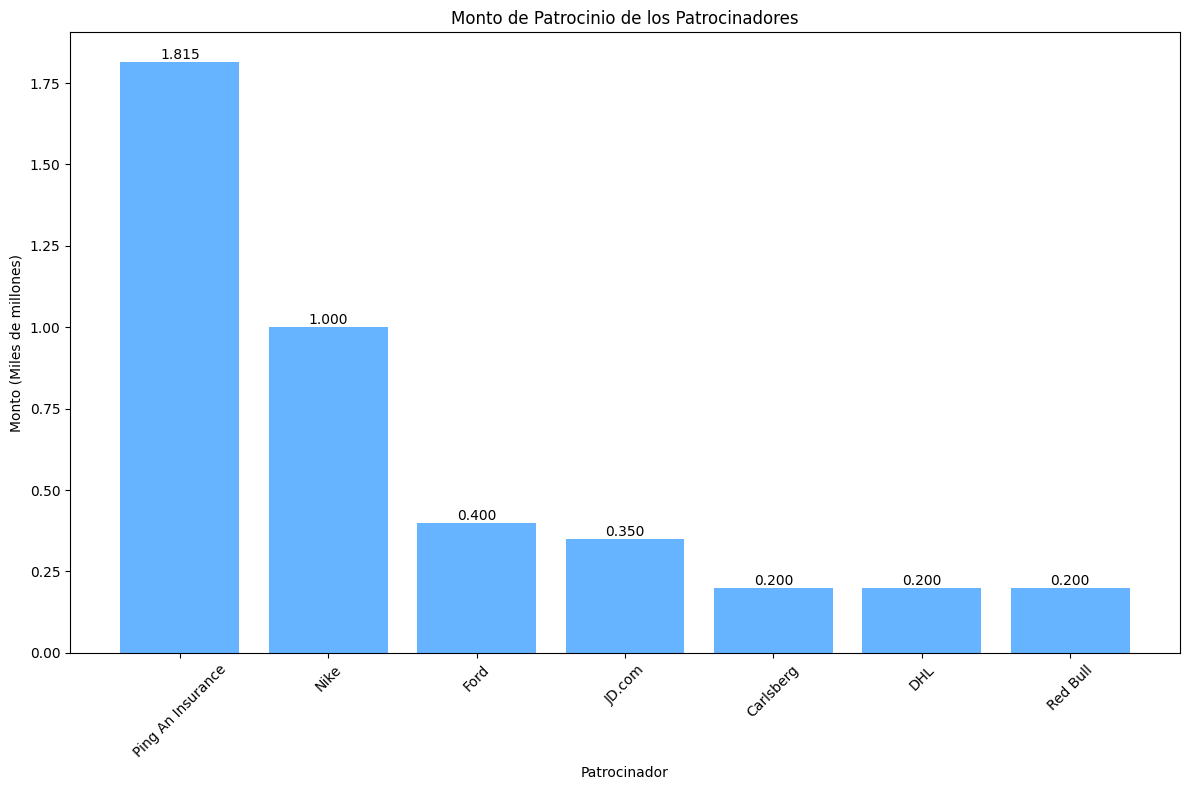

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de los patrocinadores
patrocinadores = {
    "Ping An Insurance": 1.815,
    "Nike": 1,
    "Ford": 0.4,
    "JD.com": 0.35,
    "Carlsberg": 0.2,
    "DHL": 0.2,
    "Red Bull": 0.2
}

# Crear un lienzo
plt.figure(figsize=(12, 8))

# Gráfico de barras de los montos de patrocinio
nombres_patrocinadores = list(patrocinadores.keys())
valores_patrocinadores = list(patrocinadores.values())
barras = plt.bar(nombres_patrocinadores, valores_patrocinadores, color='#66b3ff')
plt.title('Monto de Patrocinio de los Patrocinadores')
plt.xlabel('Patrocinador')
plt.ylabel('Monto (Miles de millones)')
plt.xticks(rotation=45)

# Agregar etiquetas numéricas
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.3f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 文件: chart_22_4.py

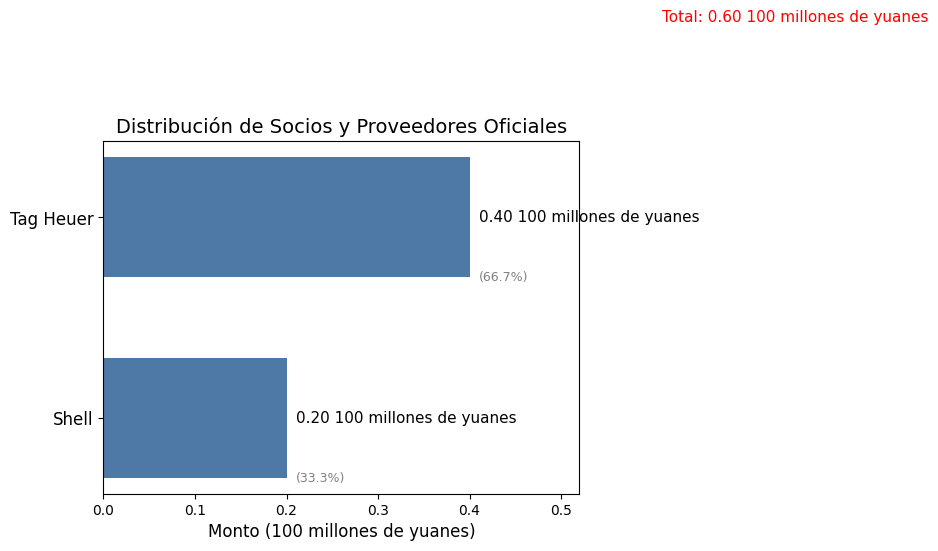

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de socios oficiales
socios = {
    "Shell": 0.2,
    "Tag Heuer": 0.4
}

# Calcular el monto total
total = sum(socios.values())

# Crear una figura
plt.figure(figsize=(10, 6))

# Gráfico de barras horizontales de socios oficiales
nombres_socios = list(socios.keys())
valores_socios = list(socios.values())

# Trazar el gráfico de barras horizontales
posicion_y = np.arange(len(nombres_socios))
barras = plt.barh(posicion_y, valores_socios, align='center', color='#4e79a7', height=0.6)
plt.yticks(posicion_y, nombres_socios, fontsize=12)
plt.xlabel('Monto (100 millones de yuanes)', fontsize=12)
plt.title('Distribución de Socios y Proveedores Oficiales', fontsize=14)
plt.xlim(0, max(valores_socios) * 1.3)  # Ajustar el rango del eje x para dejar espacio para las etiquetas

# Agregar etiquetas de valor en las barras
for i, v in enumerate(valores_socios):
    plt.text(v + 0.01, i, f'{v:.2f} 100 millones de yuanes', va='center', fontsize=11)
    plt.text(v + 0.01, i - 0.3, f'({v/total*100:.1f}%)', va='center', fontsize=9, color='gray')

# Agregar información del total
plt.axvline(x=total, color='r', linestyle='--', alpha=0.5)
plt.text(total + 0.01, len(nombres_socios), f'Total: {total:.2f} 100 millones de yuanes', va='center', fontsize=11, color='red')

plt.tight_layout()
plt.show()

# 文件: chart_22_5.py

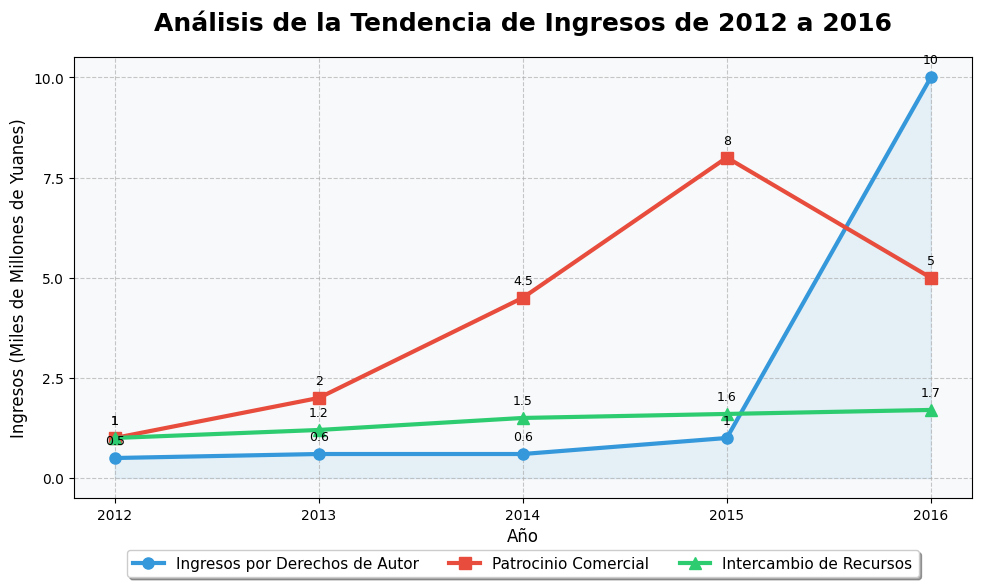

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Años
years = np.arange(2012, 2017)
# Datos simulados, siguiendo aproximadamente la tendencia del gráfico original, ingresos por derechos de autor, patrocinios comerciales, intercambio de recursos
copyright_income = [0.5, 0.6, 0.6, 1, 10]
sponsorship_income = [1, 2, 4.5, 8, 5]
resource_swap = [1, 1.2, 1.5, 1.6, 1.7]

# Crear un gráfico
fig, ax = plt.subplots(figsize=(10, 6))  # Aumentar el tamaño del gráfico

# Establecer la cuadrícula de fondo y el color
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.7)

# Dibujar tres líneas con colores y marcadores más bonitos
line1, = ax.plot(years, copyright_income, color='#3498db', label='Ingresos por Derechos de Autor', linewidth=3, marker='o', markersize=8)
line2, = ax.plot(years, sponsorship_income, color='#e74c3c', label='Patrocinio Comercial', linewidth=3, marker='s', markersize=8)
line3, = ax.plot(years, resource_swap, color='#2ecc71', label='Intercambio de Recursos', linewidth=3, marker='^', markersize=8)

# Establecer el título y el subtítulo
ax.set_title('Análisis de la Tendencia de Ingresos de 2012 a 2016', fontsize=18, fontweight='bold', pad=20)

# Establecer las etiquetas y las marcas de los ejes
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Ingresos (Miles de Millones de Yuanes)', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels([f'{year}' for year in years], fontsize=10)
ax.set_yticks(np.arange(0, 11, 2.5))

# Agregar etiquetas numéricas a cada punto de datos
for x, y in zip(years, copyright_income):
    ax.annotate(f'{y}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
for x, y in zip(years, sponsorship_income):
    ax.annotate(f'{y}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
for x, y in zip(years, resource_swap):
    ax.annotate(f'{y}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

# Resaltar el crecimiento de los ingresos por derechos de autor
ax.fill_between(years, copyright_income, 0, color='#3498db', alpha=0.1)

# Ajustar la posición y el estilo de la leyenda
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=3, fontsize=11)

plt.tight_layout()  # Ajustar el diseño
plt.show()